# Linear Regression:

**Y = wX + b**

Y --> Dependent Variable

X --> Independent Variable

w --> weight (slope)

b --> bias (intercept)

## **Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

## **Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

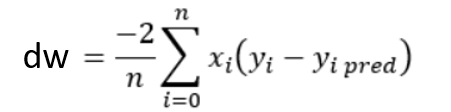

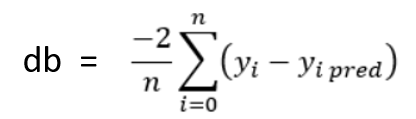

In [79]:
# importing numpy library
import numpy as np

## **Linear Regression**

In [80]:
class Linear_Regression():

  # initiating the Hyper parameters (learning rate & no. of iterations)
  def __init__(self, learning_rate, no_of_iterations): # Self -> our instance model value

    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations


  def fit(self, X, Y ):  # Function used to train the model

    # number of training examples & number of features. X -> experience Y -> Salary

    self.m, self.n = X.shape  # -> m = number of rows(no.datapoints) & n = columns(no. of features) (30,1)

    # initiating the weight and bias

    self.w = np.zeros(self.n) # 0 for many features or columns (array)
    self.b = 0 # always an integer
    self.X = X # Feature
    self.Y = Y # Salary(Target)

    # implementing Gradient Descent for model Optimization

    for i in range(self.no_of_iterations):
      self.update_weights()  # Go through the data as per the iterations and evertime change the value of w and b to get optimised model


  def update_weights(self):  # Function used to update the parameters using Gradinet Descent

    Y_prediction = self.predict(self.X)

    # calculate gradients

    dw = - (2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m

    db = - 2 * np.sum(self.Y - Y_prediction)/self.m

    # upadating the weights

    self.w = self.w - self.learning_rate*dw
    self.b = self.b - self.learning_rate*db

    # Line function for prediction

  def predict(self, X):

    return X.dot(self.w) + self.b # eq. of the line



y = 0(x) + 0,  For the First Iteration

## WorkFlow of the Model :
1. Set Learning rate and epochs value by yourself, initiate random w and b value
2. Build Linear Reg. equation. y = wx + b
3. Find the Y_Predict value from our model for the respective w and b.
4. check loss function of these parameters values. (true y - predict.y)
5. Update the parameters values using Gradient Descent (new w & b)
6. Above steps are repeated for the no. of iterations we setted and it stops for the global min value convergene for the Best Fit.

Finally, got the best fit model for best values of w and b with min loss function.

## Building the Prediction Model

# Importing the Dependencies

In [81]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Data Pre-Processing

In [82]:
# Loading the dataset to pandas Dataframe
salary_data = pd.read_csv('salary_data.csv')

In [83]:
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [84]:
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [85]:
salary_data.shape

(30, 2)

In [86]:
salary_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [87]:
# Checking for null or missing values
salary_data.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

## Splitting the Features and the Target

In [88]:
X = salary_data.iloc[:,:-1].values
Y = salary_data.iloc[:,1].values

In [89]:
print(X)
print(Y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


## Splitting Training Testing Data

In [90]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.33, random_state=2)

In [91]:
print(X_train.shape, X_test.shape, X.shape)

(20, 1) (10, 1) (30, 1)


## Training the Linear Regression Model

In [92]:
model = Linear_Regression(learning_rate=0.02, no_of_iterations=1000)

In [93]:
model.fit(X_train,Y_train)

In [94]:
# Printing Parameters values (w and b)
print('weight:', model.w[0])
print('Bias:', model.b)

weight: 9514.400999035135
Bias: 23697.406507136307


salary = 9514(years_of_exp) + 23697

## Predict Salary Value for Test Data

In [95]:
test_data_predict = model.predict(X_test)

In [96]:
print(test_data_predict)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


## Visualizing the predicted Valued and Actual Values

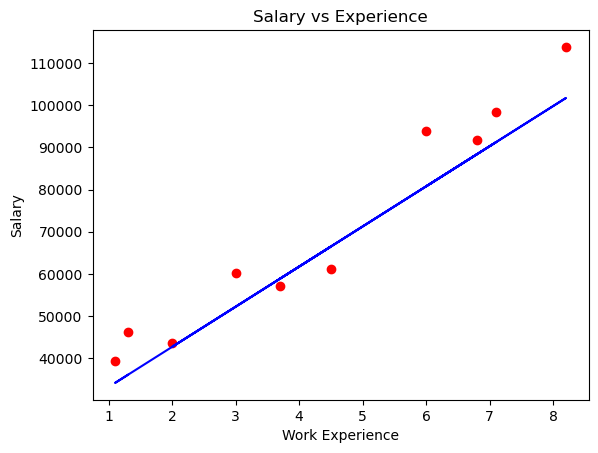

In [97]:
plt.scatter(X_test,Y_test ,color='red')
plt.plot(X_test,test_data_predict,color='blue')
plt.xlabel('Work Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()